# 3. Causal Inference: A Practical Approach

This chapter moves from the potential outcomes framework into causal modelling.
It introduces the fundamentals of causal graphs and outlines the high-level inference process.
Each stage of this process is examined in detail, covering common methods and techniques.
The chapter concludes with a case study using the Lalonde dataset to compare and contrast the different approaches discussed.

## 3.1: Causal Inference: Logical Flow

The previous chapter introduced the causality flowchart for estimating causal effects, as illustrated in the following figure.

<center>
<img src="images/logical_flow_explained.jpg" alt="Causality Flowchart: From a Target Causal Estimand to an Estimate." width="400"/>
</center>

###### Caption - Causality flowchart: From a target causal estimand to an estimate

This chapter addresses two key questions, as illustrated in the following figure:

1. **How are causal estimands converted into statistical estimands?**

   _This identification process is achieved through causal modelling._

2. **How is the final estimation performed?**

   _Once statistical estimands are defined, they are calculated using observational data and specific statistical techniques._

<center>
<img src="images/potential_outcome_estimation_how.png" alt="Causality Flowchart: From a Target Causal Estimand to an Estimate." width="400"/>
</center>

###### Caption - Causality Flowchart: How to go from a target causal estimand to an estimate using causal modeling

> Causal models are built using domain expertise to identify relevant variables and their relationships.
> Alternatively, they can be created through automated "causal discovery" methods, which are covered in Chapter 4.

## 3.2: Causal Inference: Practical Flow

The section above revisited the logical workflow to transition from a target causal estimand to an estimate. Here we focus on the practical side of this process, providing a high-level overview of the steps involved.

 This section bridge the gap between theory and practice, showing how causal inference unfolds in real-world scenarios.

Notice that the causal inference process involves distinct steps unlike the machine learning process. The following picture by Dow summarises the steps.

<center>
<img src="images/inferencing_process.png" alt="The causal infernece process in practice." width="400"/>
</center>

###### Figure: The causal inference process in practice.

1. One method to start a causal modelling process is to construct a causal graph from appropriate structural assumptions.
   Causal graphs describe the causal structure by using nodes and edges to represent variables and the causal relationships among them.

2. The following stage of causal analysis after the causal assumptions are settled is identification.
   During this stage, the causal model and the relationships between variables and observed variables in particular are examined to make sure that there is sufficient information to answer a particular causal question.
   Causal estimand are converted in statistical estimands by using differtent techniques.

3. Once confirmed that the causal effect can be estimated and that the causal estimands can be transformed in statistical estimands, the third step consists in estimating the effect using suitable statistical estimators.
   The causal effect is estimated with different estimation techniques like regression models or propensity score matching.

4. The forth and final step consists in validating and assessing the robustness of the result though rigorous checks and sensitivity analysis.
   This step includes
   - examining the sensitivity of the estimated effect to different model specifications,
   - testing the robustness of the results against potential sources of bias or unobserved confounding,
   - and assessing the generalisability of the findings.


## 3.3: Causal Modelling

The initial phase of any causal inference problem involves constructing causal models (graphical models, in particular), which encode the domain understanding and assumptions.
Well-designed causal models capture most relationships between outcome and variables and between variables.
Causal graphs are a common way to represent the relationships between variables when modelling the joint distribution.

> A cause in a Directed Acyclic Graph (DAG) (as in Bayesian networks) is defined such that a response or corresponding modifications are observed into the neighbours of the node subject to some changes.
  In the context of graphical models, a causal graph is a Bayesian network in which the direct causes of each node are represented bhy its parents.

Refer to the work by Judea Pearl for a comprehensive and in-depth exploration of causal graphs.


### 3.3.1: Assumptions in Causal Modelling

The following figure shows the complete flow of assumptions that help in causal modelling.

- *Local Markov Assumption:* given the parents in a DAG, a node is independend of all its non-descendants.
- *Minimality assumption:* adjacent nodes in a DAG are dependent and have to be considered in the factorisation in addition to the local Markov assumption.
  This assumption removes independent assumptions when the adges are present in the DAG.
- *Causal Edge assumption:* in causal relationships, every parent is the direct cause of their children.

<center>
<img src="images/causal_graphs.png" alt="Causal graph assumptions." width="400"/>
</center>

###### Figure: Causal graph assumptions.

So for a given distribution represented by DAGs:
- the local Markov assumption helps to measure statistical independence,
- the minimality assumption helps to focus on statistical dependencies (at least between the adjacent nodes),
- and finally, layering the causal edge assumption gives us the causal dependencies.



### 3.3.2: Building Blocks in Causal Graphs

In graph theory, (flow of) "association" describes whether two nodes connect, reflecting statistical dependence or independence.
This summary covers key terms and analyses of conditional independence within graph structures.


#### 3.3.2.1: Chains

A chain is a node sequence where each node is the parent of the next (see [Figure 3.5](#fig-chains)).

In a causal structure, $X_1$ and $X_2$ are dependent, as are $X_2$ and $X_3$.
$X_1$ and $X_3$ are dependent through $X_2$.
Conditioning on $X_2$ makes $X_1$ and $X_3$ independent, blocking their association.

<center>
  <img
    src="images/chain_flow_vs_blocked.png"
    alt="Association flow in chains without conditioning and with conditioning"
    width="400"/>
  <a id="fig-chains"></a>
  <h6>Figure 3.5: Association flow in chains without conditioning and with conditioning</h6>
</center>


#### 3.3.2.2: Forks

In a fork ([Figure 3.6](#fig-forks)), $X_1$ and $X_3$ are dependent via $X_2$.
Conditioning on $X_2$ makes them independent, blocking the association.

<center>
  <img
    src="images/fork_flow_vs_blocked.png"
    alt="Association flow in forks without conditioning and with conditioning"
    width="400"/>
  <a id="fig-forks"></a>
  <h6>Figure 3.6: Association flow in forks without conditioning and with conditioning</h6>
</center>


#### 3.3.2.3: Immoralities

An immorality in a DAG occurs when a node ($X_2$) has two unconnected parents ($X_1$ and $X_3$), making $X_2$ a collider.
This blocks association between $X_1$ and $X_3$ unless conditioned on, when dependence persists.

<center>
  <img
    src="images/immorality_flow_vs_conditioned.png"
    alt="Association flow in immoralities without conditioning and with conditioning"
    width="400"/>
  <a id="fig-immorality"></a>
  <h6>Figure 3.7: Association flow in immoralities without conditioning and with conditioning</h6>
</center>


3.3.2.4 Blocked Path

A blocked path relates to causal influence flow.
Paths between nodes $X$ and $Y$ may be blocked by conditioning sets $(Z)$.


1. If there exists a node $W$ on the path from $X$ to $Y$ such that it is part of a chain structure ($X \longrightarrow W \longrightarrow Y$) or a fork structure ($X \longleftarrow W \longrightarrow Y$), and $W$ is conditioned on $(W \in Z)$.
2. There is a collider $W$ on the path that is not conditioned on $(W \notin Z)$, and none of its descendants are conditioned on, i.e. $(de(W) \notin Z)$.


#### 3.3.2.5: d-Separation

d-separation depends on blocked paths.
A path from $X$ to $Y$ is blocked by $Z$ if $Z$ contains a node that blocks the path.

d-separation means $X$ and $Y$ are conditionally independent given $Z$.
If any unblocked path exists between $X$ and $Y$ given $Z$, they are not d-separated (and thus not conditionally independent).

$$X \perp_G Y |Z \implies X \perp_P Y|Z$$


### 3.3.3: Causal Graphs and Structural Interventions

In causal graphs, a **structural intervention** uses an external variable $I$ with on/off states.
- **I off**: Recovers the observed distribution.
- **I on**: Removes all incoming arrows to the target variable, making its distribution solely determined by the intervention.

Consider a causal graph where smoking and age directly cause cancer ([Figure 3.8](#fig-intervention)).
An intervention on smoking (with states 'on' or 'off') isolates its causal effect: when active, other influences on cancer (like age) are removed, making cancer a deterministic function of smoking alone.

<center>
  <img
    src="images/intervention.png"
    alt="Structural Interventions"
    width="400"/>
  <a id="fig-intervention"></a>
  <h6>Figure 3.8: Structural Interventions</h6>
</center>

For multiple simultaneous structural interventions, each variable's distribution is independent.
All edges connected to intervened variables are removed, yielding a post-intervention graph that represents the new distribution.


### 3.3.4: Observational Data and Interventional Data

Observational and interventional data terminology is key to understanding causality.

Observational data is passively collected without intervention, unlike interventional data gathered through active manipulation (e.g., randomised trials).
Observational studies face biases like confounding, making causal links hard to distinguish.

Interventional data is the gold standard for establishing causal links, as it involves actively manipulating an independent variable and observing effects on the dependent variable.
Random assignment in trials minimises confounding biases.

Observational data is typically less resource-intensive than interventional data, which is often costly and impractical to obtain.
Can interventional data be derived from observational data?


### 3.3.5: The _do_-operator and Interventions

> <p>💡 <b>Tip</b></p>
>
> The do-operator distinguishes interventional from observational distributions.
> Identification determines which causal relationships can be inferred from observed data.

The *do*-operator $do(T=t)$ denotes the entire population under intervention, distinct from the **conditional** distribution $P(Y|T=t)$, which describes only the subset with $T=t$ ([Figure 3.9](#fig-conditionalvsinterventional)).
Interventional effects require experiments; conditional effects can be derived from observational data.

The potential outcome $P(Y(t)=y)$ under intervention via the _do_-operator is given by:

$$P(Y(t)=y) \triangleq P(Y=y | do(T=t)) \triangleq P(y | do(t))$$

The average treatment effect (ATE) for binary treatment is defined via the _do_-operator.

$$ATE = \mathbb{E}[Y|do(T=1)] − \mathbb{E}[Y|do(T=0)]$$

<center>
  <img
    src="images/conditional_vs_interventional.png"
    alt="Conditional vs Interventiona"
    width="400"/>
  <a id="fig-conditionalvsinterventional"></a>
  <h6>Figure 3.9: Conditional vs Interventional</h6>
</center>


### 3.3.6: Modularity assumptions

Modularity assumes interventions affect causal graphs locally.
It is also called invariance, autonomy or independent mechanisms.

The modularity assumption states that intervening on a node $X_i$ only changes its mechanism $P(x_i|pa_i)$, leaving all other mechanisms $P(x_j|pa_j)$ (for $j \neq i$) unchanged.
Violating this means intervening on $X_i$ affects non-parent nodes' mechanisms, breaking local computation assumptions ([Figure 3.10](#fig-parents)).

<center>
  <img
    src="images/parents.png"
    alt="Modularity and Interventions"
    width="400"/>
  <a id="fig-parents"></a>
  <h6>Figure 3.10: Modularity and Interventions</h6>
</center>


### 3.3.7: Modularity Assumptions and Truncated Factorization

The network factorisation for [Figure 3.10](#fig-parents) is:

$$P(x_1, \dots, x_n) = \prod_i P(x_i \mid pa_i)$$

After intervening on set $S$, the factorisation becomes:

$$P(x_1, \dots, x_n \mid do(S=s)) = \prod_{i \notin XS} P(x_i \mid pa_i)$$,
or $0$ if inconsistent.

This truncated form estimates the causal effect $P(y \mid \text{do}(T))$ in a three-variable graph ($X$, $Y$, $T$) with $X$ as a confounder ([Figure 3.11](#fig-truncated)).

<center>
  <img
    src="images/truncated_factorization.png"
    alt="Modularity and Interventions"
    width="400"/>
  <a id="fig-truncated"></a>
  <h6>Figure 3.11: Modularity and Interventions</h6>
</center>

Network factorization yields:

- Intervening on treatment T removes $P(t|x)$, yielding $P(y|x)$.

- This shows identifiability: the causal estimand $P(y|do(T))$ is identifiable from observational data as $\sum_x P(y|t,x)P(x)$ via marginalisation over $x$.

- In causal inference, $P(y|t)$ (observational) differs from $P(y|\text{do}(t))$ (interventional).
  - Observationally: $P(y|t) = \sum_x P(y|x,t)P(x|t)$.
  - Interventionally: $P(y|\text{do}(t)) = \sum_x P(y|x,t)P(x)$.

  The key difference is $P(x|t)$ versus $P(x)$, so $P(y|\text{do}(t)) \neq P(y|t)$.


### 3.3.8: Structural Causal Models (SCM)

Structural Causal Models (SCMs) are key tools in causal inference modelling, representing causal relationships between variables (Spirtes et al. 2000).

Structural Causal Models (SCMs) comprise two elements:
- Equations defining causal relationships between endogenous variables.
- Exogenous variables (external factors unaffected by others).
Causal graphs visualise these relationships.

If $X$ causes $Y$, it is written as a structural equation.

Stochasticity is added via noise variables $(U)$, so $Y = f(X, U)$.

Structural causal models (SCMs) represent multiple causal relationships via equations such as $X = f_X(W, U_X)$ and $Z = f_Z(X, Y, U_Z)$, incorporating noise terms ([Figure 3.12](#fig-scm)).

<center>
  <img
    src="images/scm.png"
    alt="Structural Causal Models"
    width="400"/>
  <a id="fig-scm"></a>
  <h6>Figure 3.12: Structural Causal Models</h6>
</center>


#### 3.3.8.1: Interventions and Modularity Assumptions in SCM

For the basic causal model ([Figure 3.13](#fig-scmintervention)) with confounder $X$ affecting treatment $T$ and outcome $Y$, the structural causal model (SCM) equations are:

$$T = f_T(X, U_T)$$

$$Y = f_Y(X, T, U_Y)$$

Under intervention, $T$ is fixed:

$$T = t$$

$$Y = f_Y(X, T, U_Y)$$

<center>
  <img
    src="images/scm_intervention.png"
    alt="Intervention and removing the edge corresponding to \(do(T=t)\)"
    width="400"/>
  <a id="fig-scmintervention"></a>
  <h6>Figure 3.13: Intervention and removing the edge corresponding to \(do(T=t)\)</h6>
</center>


## 3.4 Identification

> <p>💡 <b>Tip</b></p>
>
> Identification converts causal effects $P(Y|do(t))$ to observable relationships $P(Y|t)$. 
> If this conversion is possible, the effect is identifiable.

This section examines a simple identification with treatment $(T)$, confounding variable $(X)$, and outcome $(Y)$ ([Figure 3.14](#fig-identification)).

<center>
  <img
    src="images/identification.png"
    alt="Identification"
    width="400"/>
  <a id="fig-identification"></a>
  <h6>Figure 3.14: Identification</h6>
</center>

**Identification** refers to computing $P(y \mid \text{do}(T))$, derived from the joint distribution:

$$P(y,t,x) = P(x)P(t|x)P(y|t,x)$$

Under modularity, intervening on $T$ gives $P(T|X)=1$, so:

$$P(y,x|\text{do}(T)) = P(x)P(y|T,x)$$

and marginalising the variable $(X)$:

$$P(y|\text{do}(T)) = \sum_x P(y|t,x)P(x)$$

The **adjustment formula** expresses the causal effect using observed data: $\sum_x P(y|t,x)P(x)$.

> <p>💡 <b>Tip</b></p>
>
> As shown in [Figure 3.15](#fig-identificationmath), the identification process transforms the causal estimand $P(y|\text{do}(T))$ into the statistical estimand $\mathbb{E}_X[P(y|t,X)]$ or $P(y|t)$, depending on whether confounders exist.

<center>
  <img
    src="images/identification_with_without_confouders.png"
    alt="Identification in presence or absence of confouding variable"
    width="400"/>
  <a id="fig-identificationmath"></a>
  <h6>Figure 3.15: Identification in presence or absence of confouding variable</h6>
</center>

Identification methods fall into two main categories with subcategories.

* Graphical Constraint-based Methods+ Randomized Control Tests
  + Backdoor Adjustments
  + Frontdoor Adjustments
* Non-Graphical Constraint-based Methods+ Instrumental Variables
  + Regression Discontinuity
  + Difference-in-Differences
  + Pearl's do-calculus

Next, we cover these identification methods.



### 3.4.1 Randomized Control Trials (RCT)

Randomised controlled trials eliminate confounding by ensuring treatment groups ($T=0$ and $T=1$) are comparable through random allocation. 
This creates exchangeability, meaning the groups are interchangeable. 
Consequently, average outcomes ($\mathbb{E}[Y|T=1] = y_1$ and $\mathbb{E}[Y|T=0] = y_0$) remain equal. 
Causally, randomisation breaks the link between confounders $(X)$ and treatment $(T)$, removing backdoor paths.


### 3.4.2 Backdoor Criterion and Backdoor Adjustment

Causal graphs show paths from treatment $(T)$ to outcome $(Y)$, including causal and non-causal routes. 
Identification is achieved by blocking backdoor paths—those entering $T$ (<a href="#ref-pearl2010causal">Pearl 2010</a>).

[Figure 3.16](#fig-observationalvscausal) shows the observational graph (left) with multiple paths between treatment $(T)$ and outcome $(Y)$, including both causal and non-causal routes. Only one path $T \longrightarrow X \longrightarrow Y$ is causal; others like $T \longrightarrow W \longrightarrow U \longrightarrow V \longrightarrow Y$ are non-causal backdoor paths.
The interventional graph (right, $P(Y | \text{do}(t))$) blocks all non-causal backdoor paths by removing edges.

<center>
  <img 
    src="images/observational_vs_causal.png"
    alt="Observational Vs Causal"
    width="400"/>
  <a id="fig-observationalvscausal"></a>
  <h6>Figure 3.16: Observational Vs Causal</h6>
</center>

An interventional causal graph can be derived from an observational one by conditioning on variables in backdoor paths.
Conditioning on $W$ and $X$ blocks these paths, making $P(Y \mid t, w, x)$ equivalent to the interventional distribution, as shown in [Figure 3.17](#fig-causalvsconditoning).

<center>
  <img 
    src="images/causal_vs_conditioning.png"
    alt="Causal vs Conditoning"
    width="400"/>
  <a id="fig-causalvsconditoning"></a>
  <h6>Figure 3.17: Causal vs Conditoning</h6>
</center>

A set $Z$ satisfies the backdoor criterion for treatment $T$ and outcome $Y$ if:

* If set $Z$ blocks all backdoor paths from $T$ to $Y$.
* $Z$ contains no descendants of $T$.

Thus, using the modularity assumption and backdoor criterion, the causal effect can be identified.

$P(y| \text{do}(t)) = \sum_z P(y|t,z) P(z)$


### 3.4.3 Front-door Adjustments

Judea Pearl's front-door method addresses smoking's effect on cancer via tar (mediator), despite an unobserved genotype confounder ([Figure 3.18](#fig-pearlfrontdoor)).
The backdoor criterion fails here due to the unobserved confounder.

<center>
  <img
    src="images/pearl_frontdoor.png"
    alt="Cancer and Smoking relationship"
    width="400"/>
  <a id="fig-pearlfrontdoor"></a>
  <h6>Figure 3.18: Cancer and Smoking relationship</h6>
</center>

The generic DAG is shown in [Figure 3.19](#fig-genericfrontdoor).
The front-door adjustment intuition breaks down into three steps.

<center>
  <img
    src="images/generic_frontdoor.png"
    alt="Generalized Front-door"
    width="400"/>
  <a id="fig-genericfrontdoor"></a>
  <h6>Figure 3.19: Generalized Front-door</h6>
</center>

* No backdoor paths imply $P(m \mid \text{do}(t)) = P(m \mid t)$.
* To find $M$'s causal effect on $Y$ $P(y|do(m))$, condition on $T$ to block the backdoor path via $T$.

$$P(y|do(m) = \sum_t P(y|m,t)P(t)$$

* The frontdoor adjustment estimates the causal effect of treatment $(T)$ on outcome $(Y)$ using mediators $(M)$, when direct paths are blocked.
  $M$ satisfies the frontdoor criterion if:
  - It blocks all paths from $T$ to $Y$;
  - All paths from $T$ to $M$ are unconfounded.

1. Variable $M$ mediates the effect of $T$ on $Y$.
2. No backdoor path exists from $T$ to $M$.
3. All backdoor paths from $M$ to $Y$ are blocked by $T$.


### 3.4.4 Instrumental Variable Analysis

Instrumental variables affect treatment (e.g. cigarette prices influencing smoking) but not the outcome (e.g. cancer risk), as shown in [Figure 3.20](#fig-ivexample) (Pearl, 2010).

<center>
  <img
    src="images/iv_example.png"
    alt="Example of Instrumental Variables"
    width="400"/>
  <a id="fig-ivexample"></a>
  <h6>Figure 3.20: Example of Instrumental Variables</h6>
</center>

**Instrumental variables resolve endogeneity by isolating treatment's causal effect on outcome. The IV must be uncorrelated with errors, affect treatment, but not outcome directly.**

The instrumental variable method uses a two-stage process ([Figure 3.21](#fig-ivgeneral)):

1. Regress treatment ($\hat{T}$) on instrument ($Z$): $\hat{T} = \beta_0 + \beta_1 Z$.
2. Regress outcome ($Y$) on predicted treatment ($\hat{T}$): $\hat{Y} = \beta_2 + \beta_3 \hat{T}$.
3. It requires moderate confounding and a sufficient sample size.

<center>
  <img
    src="images/iv_generic.png"
    alt="Generalized relationship between Instrumental Variables, Treatment, and Outcome"
    width="400"/>
  <a id="fig-ivgeneral"></a>
  <h6>Figure 3.21: Generalized relationship between Instrumental Variables, Treatment, and Outcome</h6>
</center>


### 3.4.5 Regression Discontinuity

This method identifies causal effects at a threshold where treatment (e.g., scholarships, medicine) is assigned based on an outcome (e.g., test scores, cholesterol levels, see [Figure 3.22](#fig-regressiondiscontinuity)).
It compares outcomes just above and below the threshold.
The key measure is the discontinuity coefficient $(β_2)$ in the regression:

$$\hat{y} = β_0 + β_1 X + β_2 I(x > x_0)$$

<center>
  <img
    src="images/regression_discontinuity.png"
    alt="Regression Discontinuity"
    width="400"/>
  <a id="fig-regressiondiscontinuity"></a>
  <h6>Figure 3.22: Regression Discontinuity</h6>
</center>


### 3.4.6 Difference-in-Differences

The **Difference-in-Differences (DID)** method estimates treatment effects over time by comparing outcome changes between treatment and control groups using regression analysis (Lechner et al., 2011).

<center>
  <img
    src="images/did.png"
    alt="Difference-in-Differences"
    width="400"/>
  <a id="fig-did"></a>
  <h6>Figure 3.23: Difference-in-Differences</h6>
</center>

For a binary treatment (T=0/1) with a time-measured real-valued outcome (y), regression uses variables D (treatment) and T (time), as shown in [Figure 3.23](#fig-did).

The regression model $y = \beta_0 + \beta_1D + \beta_2T + \beta_3D \times T + \mu$ estimates:

- $\beta_1$: treatment effect,
- $\beta_2$: control group's time trend,
- $\beta_3$: interaction effect (treatment impact).

- Assumptions include common pre-treatment trends and no autocorrelation.


### 3.4.7 Pearl's _do_-calculus

For a do-query like $Q = P(y \mid \text{do}(x), z)$, Pearl's _do_-calculus determines identifiability.
It identifies causal effects when backdoor and front-door adjustments fail (Pearl, 2012).

In a causal DAG $G$ with disjoint node sets $X$, $Y$, $Z$, $W$:
- $G_\overline{X}$ removes all edges into $X$.
- $G_underline{X}$ removes all edges out of $X$.
- $G_{\overline{X}\underline{Z}}$ removes both for $X$ and $Z$.

Three rules govern all interventional distributions under $G$-structure.

1. **Rule 1: Insertion or deletion of observations**

   Rule 1: Ignore observational nodes that don't affect the outcome or are d-separated from it.

   If Y and Z are d-separated given X and W in $G_{\overline{X}}$, then $P(y \mid \text{do}(x), z, w) = P(y \mid \text{do}(x), w)$.

2. **Rule 2: Action-observation exchange**

   In randomised trials, researchers assign treatments ($\text{do}(x)$ or not).
   With observational data, direct intervention isn’t feasible.
   Rule 2 enables treating interventions $\text{do}(x)$ as standard observational data.

   Under Rule 2, interventions $\text{do}(x)$ can be treated as observations when $X \longrightarrow Y$ affects $Y$ only via directed paths.

   For causal inference, if $Y \perp Z \mid X, W$ holds in graph $G_{\overline{X}\underline{Z}}$, then $P(y \mid \text{do}(x), \text{do}(z), w) = P(y \mid \text{do}(x), z, w)$.
   This allows replacing $\text{do}(z)$ with observed $z$, using only observational data.

3. **Rule 3: Insertion/deletion of actions**

   Remove $\text{do}(z)$ if no causal path links $Z$ to $Y$.

   The equality holds if $Y$ is conditionally independent of $Z$ given $X$ and $W$ in the causal graph.

   Both front-door and backdoor adjustments follow from _do_-calculus.
   As it is complete (Shpitser & Pearl, 2006), any causal query requiring uneliminated _do_-operations is unidentifiable.


## 3.5: Estimation

This section covers methods for estimating statistical estimands.

There are two main estimation methods.

**Covariate Adjustment Methods**

Covariate adjustment uses features $(X)$ and treatment $(T)$ to predict outcomes $(Y)$ via machine learning models.
Model choice (linear or non-linear) depends on variable relationships.
Common techniques include:

1. COM Estimator
2. GCOM Estimator
3. X-Learner
4. TarNET
5. Matching
6. Doubly Robust Learners

**Propensity Score Methods**

The propensity score is the probability of treatment given observed covariates.
It balances covariate distributions between treated and control groups, creating a pseudo-population where differences are adjusted for.

Propensity score methods include:

1. Propensity Score Matching
2. Propensity Score Stratification
3. Inverse Propensity Score Weighting


#### 3.5.0.1: Conditional Outcome Modeling Estimator (COM Estimator or S-Learner)

The **Individualised Treatment Effect (ITE)** is unknowable (see Chapter 2).
Large randomised experiments measure the **Average Treatment Effect (ATE)**, defined as:

$$\tau = \mathbb{E}[Y_i(1) - Y_i(0)]$$

With covariates (observed or unobserved), the **Conditional Average Treatment Effect (CATE)** estimates a more specific effect.

$$\tau(x) \triangleq \mathbb{E}[Y(1)-Y(0)|X=x]$$

Assuming $W \cup X$ is a sufficient adjustment set satisfying the backward criterion, unconfoundedness holds.

The ATE is given by:

$$\tau \triangleq \mathbb{E}[Y(1) - Y(0)] = \mathbb{E}_W\bigl[ \mathbb{E}[Y|T=1,W] - \mathbb{E}[Y|T=0,W] \bigr]$$

where $\tau$ represents the causal effect, equivalent to the statistical estimand $\mathbb{E}_W\bigl[\mathbb{E}[Y|T=1,W] - \mathbb{E}[Y|T=0,W]\bigr]$.

A machine learning model (e.g., regression) approximates the statistical estimand $\mu$ by estimating $\mathbb{E}[Y|T,W]$ and using the empirical mean $\bigl(\frac{1}{n} \sum_i\bigr)$ over all data $(n)$ to approximate $\mathbb{E}_W$.

The conditional average treatment effect is $\mu(1,W) - \mu(0,W) = \mathbb{E}[Y|T=1,W] - \mathbb{E}[Y|T=0,W]$.
The conditional outcome model (COM estimator or S-Learner) is defined by Künzel et al. (2019).

The ATE using the COM estimator is denoted as $\hat{\tau}$ and is the mean difference between treated and control outcomes:

$$\tau = \frac{1}{n} \sum_i \bigl( \hat{\mu}(1, w_i) - \hat{\mu}(0, w_i) \bigr)$$

The CATE estimator using adjustment set $W$ and all covariates $X$ via model $\mu$.

$$\hat{\mu}(t,w,x) \triangleq \mathbb{E}[Y \mid T=t, X=x, W]$$

The model $\hat{\mu}(t,w,x)$ computes the conditional expectation $\mathbb{E}[Y \mid T=t, X=x, W]$.

The statistical model $\hat{\tau}$ is used to compute the CATE $\tau x$ using the COM estimator as:

$$\hat{\tau}(x) = \frac{1}{n_x} \sum_{i: x_i=x} \bigl( \hat{\mu}(1,w_i,x) - \hat{\mu}(0,w_i,x) \bigr).$$

ITE, the key measure, is approximated as the difference between two model predictions:

$$\tau_i = \hat{\mu}(1, w_i, x).$$


### 3.5.1: Grouped Conditional Outcome Modeling Estimator (GCOM Estimator)

In most cases, treatment $T$ is binary while adjustment covariates $W \cup X$ are high-dimensional.
Standard conditional outcome models (COM) fail here: fitting $\hat{\mu}(1,w_i) - \hat{\mu}(0,w_i)$ ignores $T$, biasing the **Average Treatment Effect (ATE)** toward zero.

The **Grouped Conditional Outcome Model (GCOM)** estimator resolves this by:

- Fitting separate models $\hat{\mu}_1(w)$ for $T=1$ and $\hat{\mu}_0(w)$ for $T=0$
- Computing $\hat{\tau}(x) = \frac{1}{n_x}\sum_{i:x_i=x} (\hat{\mu}_1(w_i,x) - \hat{\mu}_0(w_i,x))$

GCOM avoids dimensionality imbalance but uses less data than COM, as it fits models per treatment group rather than globally.


### 3.5.2: TARNet

COM estimators are biased towards zero as they combine treatment $T$ and covariates $W$.
GCOM builds separate models for each treatment ($T=0$ and $T=1$), using only part of the data and increasing variance.
TARNet learns a shared representation $\hat{\mu}$ from all covariates, then branches to two heads (see [Figure 3.24](#fig-tarnet)).

<center>
  <img
    src="images/tarnet.png"
    alt="TARNet estimator"
    width="400"/>
  <a id="fig-tarnet"></a>
  <h6>Figure 3.24: TARNet estimator</h6>
</center>


### 3.5.3: X-Learner

Kunzell et al.'s **X-learner** improves on GCOM by using all data to estimate CATE, especially for binary treatments (Künzel et al. 2019).

X-learner has the following three stages:

* **Step 1**

  If $X$ is a sufficient adjustment set for a binary treatment, estimate $\hat{\mu}_0(x)$ and $\hat{\mu}_1(x)$ using the GCOM estimator.

* **Step 2(a)**

  For the treatment group, imputed ITE is $\hat{\tau}_{1,i} = Y_i(1) + \hat{\mu}_0(x_i)$.
  For the control group, it is $\hat{\tau}_{0,i} = Y_i(0) + \hat{\mu}_1(x_i)$.
  Only group-specific data is used in both calculations.

* **Step 2(b)**

  Fit regression models:

  - $\hat{\tau}_1(x)$ predicts treatment effects using all treatment data and prior control group estimates $\hat{\mu}_0$.
  - $\hat{\tau}_0(x)$ predicts control effects using all control data and prior treatment estimates.</p>

* **Step 3**

  The estimators are combined using a weighting function $0 < g(x) < 1$.

  The authors found the propensity score works well as a weighting function.


### 3.5.4: Matching

Matching pairs treated and control groups using covariates and a distance metric (Stuart, 2010).

[Figure 3.25](#fig-matching) shows 1-NN matching in two dimensions $(X_1, X_2)$ for treated-control group matching.

<center>
  <img
    src="images/matching1.png"
    alt="Matching Algorithm"
    width="400"/>
  <a id="fig-matching"></a>
  <h6>Figure 3.25: Matching Algorithm</h6>
</center>

The following procedure is followed for 1-Nearest Neighbor (1-NN):

1. A metric $d(\cdot,\cdot)$ quantifies similarity or distance between elements.
2. $\mathcal{J}(i) = \text{argmin}_{\substack{j \neq i \\ t_j \neq t_i}} d(x_j, x_i)$
3. Individual ITEs are calculated using counterfactual outcomes:
$\hat{\tau_{i}} = (2t_i - 1)(y_i - y_{\mathcal{J}(i)})$.
4. ATE is calculated as the average of individual treatment effects across matched groups.
   Matching enables causal estimation by balancing confounders within groups, attributing differences solely to treatment.
   This method works well with few confounders but suffers from the curse of dimensionality with many.
   It remains easily interpretable for domain experts, though its effectiveness depends heavily on the chosen distance metric.

The 1-NN matching algorithm is equivalent to covariate adjustment, facilitating theoretical analysis.


### 3.5.5: Doubly Robust Estimator

Doubly robust estimators combine outcome models $\hat{\mu}(x)$ and propensity scores $\hat{e}(x)$ (Robins et al., 1994).
The treatment effect is estimated as:

$$\hat{\tau} = \frac{1}{n}\sum_i \bigl[ \hat{\mu}(1, x_i) - \hat{\mu}(0, x_i) \bigr]$$.

The doubly robust method consistently estimates the Average Treatment Effect (ATE) if either the outcome model or propensity score model is correctly specified.
It converges faster than either component estimator and is particularly valuable in high-dimensional data.


### 3.5.6: Double Machine Learning

Double machine learning (DML) uses two-stage machine learning to partial out confounders and covariates (X), see [Figure 3.26](#fig-doubleml).

<center>
  <img
    src="images/double_machine_learning.png"
    alt="Double Machine Learning"
    width="400"/>
  <a id="fig-doubleml"></a>
  <h6>Figure 3.26: Double Machine Learning</h6>
</center>

1. Stage

   1. Fit model to predict Y from X, yielding $\hat{Y}$.

   2. Fit a model to predict T from X, yielding $\hat{T}$.

2. Remove confounding by fitting a model to the residuals $(Y - \hat{Y})$ and $(T - \hat{T})$.


### 3.5.7: Causal Trees and Causal Forests

Causal trees resemble decision trees, but internal nodes use only covariates (not treatment) (Wager & Athey 2018).

1. Data is split into training and test sets.
   The training set builds the model; the test set evaluates it.

2. Causal trees split nodes to separate treated and control groups with differing outcomes, unlike standard decision trees.
   They use Kullback-Leibler (KL) divergence to measure differences in outcome distributions between groups.
   For treated group outcomes $p_i$ and control group outcomes $q_i$, KL divergence is:

$$D = \sum p_i \log \frac{p_i}{q_i}.$$

   This quantifies divergence for evaluating splits.

   To find the best split, maximise the divergence between outcome distributions in treated and control groups, weighted by covariate distribution:

$$D(P(Y|T=1):P(Y|T=0)|X) = \sum_x \frac{N_x}{N}D(P(Y|T=1,x):P(Y|T=0,x)).$$

   D_gain(X) quantifies the difference in treatment effect divergence between subgroups (X) and the overall population.

3. Cross-validation selects optimal tree depth $d*$ via pruning to minimise mean squared error (MSE) of treatment effects, using folds as test set proxies.

4. After building the tree, the test set $\mathcal{S}^{\text{test}}$ estimates treatment effects in leaf nodes.

**Causal Forests** extend **Causal Trees** to estimate the Average Treatment Effect (ATE).
Instead of using a single tree, they build many trees and average their predictions.
This approach improves estimation accuracy over a single causal tree.

$$\hat{\tau}(x) = \frac{1}{B}\sum_{b=1}^B T_b^*(x; \text{data})$$

Causal forests use multiple 'honest' trees built via subsampling and random covariates.
Each tree is trained on one data subset and estimates effects on another, reducing bias.
Averaging these trees yields unbiased estimates with asymptotic normality as sample size increases.


### 3.5.8: Propensity Score-Based

Randomised controlled trials (RCTs) provide unbiased average treatment effect estimates via random assignment (e.g., coin flip).
Propensity scores reweight observational data to mimic RCT-like data ([Imbens and Rubin 2015](#ref-imbens2015causal)).

In observational data with binary treatment and two covariates, propensity scoring reweights samples to adjust distributions.
This mimics randomised assignment by aligning group distributions.

<center>
  <img 
    src="images/propensity_before.png"
    alt="Observed data before Propensity reweighting"
    width="400"/>
  <img
    src="images/propensity_after.png"
    alt="Observed data after Propensity reweighting"
    width="400"/>
  <h6>Observed data before and after Propensity reweighting</h6>
</center>

The **propensity score**, denoted *e(W) = P(T=1|W)*, is the probability of treatment assignment (*T=1*) given the adjustment set *W*.
It can be estimated using machine learning.
Re-weighting samples by the inverse propensity score balances the treatment distribution.

The **propensity score theorem** states that, under positivity and unconfoundedness given covariates $W$, unconfoundedness also holds given the propensity score $e(W)$.
This allows replacing high-dimensional covariate adjustment with a single scalar value.

The **Inverse Propensity Weighting (IPW) Estimator** uses observed data to estimate the average treatment effect (ATE).
First, a machine learning model estimates the propensity score $\hat{p}(T=t|X)$. The ATE is then calculated as:

$$\hat{\tau} = \frac{1}{n_1} \sum_{T_i=1} \frac{Y_i}{\hat{p}(T=1|X_i)} - \frac{1}{n_0} \sum_{T_i=0} \frac{Y_i}{\hat{p}(T=0|X_i)}$$


### 3.5.9: Propensity Score Matching

**Propensity Score Matching (PSM)** mimics a Randomized Controlled Trial (RCT) by comparing outcomes between treated and untreated groups in a matched sample.

However, implementing PSM requires careful consideration of caveats.

1. Common Support requires similar treatment propensity distributions in both treated and untreated groups.
2. Second, use only baseline characteristics unaffected by the treatment during matching.
3. Confounding variables must be observable to avoid biased estimates.
4. The fourth caveat: select relevant characteristics, not all variables.

Jalan and Ravallion (2003) outline PSM.

1. Propensity scores for all units
2. Treated and control groups are matched using a predetermined strategy, such as nearest neighbour matching without replacement.
3. Evaluate covariate balance. If imbalanced, revisit earlier steps and try alternative specifications.
4. Average treatment effect


### 3.5.10: Propensity Score Stratification

King and Nielsen (2019) argue PSM aims to mimic fully randomised experiments, not blocked ones.
Their exact matching worsens imbalance, inefficiency, and bias, failing to reduce imbalance effectively.

Propensity score stratification balances covariates between treated and control groups, adjusting for imbalances using the score.

PS stratification steps:

1. Calculate propensity score via logistic regression.
2. Non-overlapping strata are set using estimated PS.
3. Treated and control units are stratified.
4. Difference in means between treated and control groups is calculated per stratum.
5. Stratum means are weighted to reach the target.

Rosenbaum and Rubin (1984) show 5 strata remove ~90% of bias.
Beyond 5–10 strata, further bias reduction is minimal (Neuhäuser et al. 2018).
Increasing strata also reduces data per stratum, limiting practicality.

In propensity score stratification, ATE weights are based on total units per stratum, while ATT weights use treated units per stratum (Imbens, 2004).


## 3.6: Evaluation and Validation Techniques

Causal model evaluation differs from traditional ML, which relies on cross-validation and test sets.
Key metrics for causal models are covered here.


### 3.6.1: Evaluation Metrics

Evaluation metrics fall into two categories depending on whether subpopulations are homogeneous or heterogeneous.

1. Standard Causal Effect Estimation
2. Heterogeneous Effect Estimation


#### 3.6.1.1 Standard Causal Effect Estimation

For real-valued outcomes across $M$ experiments, observed ATE ($\tau$) and predicted ATE ($\hat{\tau}$) enable regression-based evaluation metrics.

1. Mean Squared Error (MSE) for Average Treatment Effect (ATE):

$$\epsilon_{MSE\_ATE} = \frac{1}{M} \sum_{j=1}^M \bigl(\tau_j - \hat{\tau}_j \bigr)^2$$

2. Root Mean Squared Error (MSE) for Average Treatment Effect (ATE):

$$\epsilon_{RMSE\_ATE} = \sqrt{\frac{1}{M}\sum_{j=1}^{M}\bigl(\tau_j - \hat{\tau}_j\bigr)^2}$$

3. Mean Absolute Error (MAE) for Average Treatment Effect (ATE):

$$\epsilon_{MAE\_ATE} = \frac{1}{M}\sum_{j=1}^{M}|\tau_j - \hat{\tau}_j|$$


#### 3.6.1.2: Heterogeneous Effect Estimation

1. **Uplift Curve**

   Uplift modelling identifies individual treatment effects rather than population averages, estimating the difference in outcome with and without intervention for each person.
   The Methodology for Uplift Curve is described below.

   Similar to ROC curves, uplift curves are generated by:
   1. Calculating CATE scores (treatment-control effect estimates) per individual.
   2. Sorting individuals by descending uplift score.
   3. Computing the average treatment-control difference per decile. $$\left( \frac{Y^1}{N^1} - \frac{Y^0}{N^0} \right)(N^1 + N^0)$$ where $Y^1$, $N^1$ are the sum and number of treated outcomes, and $Y^0$, $N^0$ the sum and number of control outcomes.
   4. The uplift curve plots population percentiles (x-axis) against uplift gain per group (y-axis).

   Uplift curves let us target the decile with highest uplift, rather than the whole population.

2. **Qini Curve**

   The Qini curve is a type of uplift curve using the Qini score instead of the uplift score. $$Y^1 - Y^0 \frac{N^0}{N^1}$$ For imbalanced treatment and control groups, this measure provides better correction than the uplift score: $Y^1 - Y^0 \times \frac{N^0}{N^1}$.

3. **Uplift(Qini) Coefficient**

   The uplift coefficient (Qini) is the area under the uplift curve.

$$\text{Uplift\_Coef} = \sum_{a=0}^{N-1} \left( \text{Uplift}(a+1) + \text{Uplift}(a) \right)$$
$$\text{Qini\_Coef} = \sum_{a=0}^{N-1} \left( \text{Qini}(a+1) + \text{Qini}(a) \right)$$


### 3.6.2: Robustness Checks and Refutation Techniques

Causal inference relies on assumptions at every stage:

- **Modelling**: e.g., no unobserved variables, graph structure.
- **Identification**: e.g., parametric forms.
- **Estimation**: e.g., linear treatment-outcome relationships.
Some assumptions can be tested; others cannot be validated.

Unit and integration testing are standard software testing approaches.


#### 3.6.2.1 Unit or Modular Tests

Designing tests to verify model, identification and estimation assumptions.

1. **Conditional independence tests** validate assumptions using dependence graphs and data, e.g., for treatment $T$ and variables $X_1$, $X_2$ where $P(T|X_1, X_2) = P(T|X_1) P(T|X_2)$.
2. **D-separation tests** check conditional and marginal independence in graphical models using moralisation, edge orientation, and edge addition/deletion.
3. **Bootstrap Sample Validation** uses resampling to assess statistically significant changes in the estimand.
4. **Data Subsets Validation:** Using a random subset instead of the full dataset measures changes in estimands and assesses impact.


#### 3.6.2.2: Integration or Complete Tests

Integration testing validates how components work together, not just individual steps.

1. **Placebo Treatment Refuter:**
   Replacing treatment with a random variable (e.g., Gaussian) should yield zero effect if assumptions hold; otherwise, steps require correction.
2. **Adding Random Common Cause:**
   Adding an independent random variable as a common cause should not change the estimate.
   This can be tested on the dataset to assess significance of any change.
3. **Dummy Outcome Refuter:**
   Replacing the outcome with a random variable should yield zero causal effect.
4. **Simulated Outcome Refuter or Synth Validation:**
   This technique tests process validity by generating datasets closely replicating the original's creation process and assumptions.
   If the estimation effect remains consistent, it confirms robustness: a key comprehensive validation test.
5. **Adding Unobserved Confounder:**
   Missing observed confounders is a real-world issue.
   Simulating a confounder using correlation $\rho$ between outcome and treatment reveals estimation changes.
   A significant shift indicates a robustness problem.


## 3.7: Unconfoundedness: Assumptions, Bounds, and Sensitivity Analysis

Manski (2003) argues the no unobserved confounding assumption is unrealistic in practice, challenging common causal inference approaches.

With unobserved confounder U and observed confounder $W$, the ATE is given by the adjustment formula ([Figure 3.27](#fig-observedconfounding)).

<center>
  <img
    src="images/observed_confounding.png"
    alt="Observed Confounding"
    width="400"/>
  <a id="fig-observedconfounding"></a>
  <h6>Figure 3.27: Observed Confounding</h6>
</center>

Since $U$ is unobserved, the ATE is approximated as
$$\mathbb{E}_{W,U}[\mathbb{E}[Y \mid T=1,W,U] - \mathbb{E}[Y \mid T=0,W,U]].$$

The ATE approximation $$\mathbb{E}[Y(1) - Y(0)] \approx \mathbb{E}_{W}[\mathbb{E}[Y|T=1,W] - \mathbb{E}[Y|T=0,W]]$$ depends on assumptions, making ATE an interval rather than a single value.

If potential outcomes are bounded between 0 and 1, the individual treatment effect lies in $[-1, 1]$.
Thus, the average treatment effect (ATE) expectation is bounded by $[-1, 1]$.
Generally, for bounds $[l, h]$, the ATE interval length is $2(h - l)$.

$$l-h \leq \mathbb{E}[Y(1) -Y(0)] \leq h-l$$


### 3.7.1: Observational Counterfactual Decomposition

ATE decomposes into observational and counterfactual components.

The linearity of expectation gives:
$$\mathbb{E}[Y(1) - Y(0)] = \mathbb{E}[Y(1)] - \mathbb{E}[Y(0)].$$

Marginalising over treatment yields:

$$\begin{aligned}
\mathbb{E}\bigl[Y(1) - Y(0)\bigr] &= P(T=1)\mathbb[E]\bigl[Y(1)|T=1\bigr] + P(T=0)\mathbb{E}\bigl[Y(1)|T=0\bigr] \\
                                  &- \bigl(P(T=1)\mathbb{E}\bigl[Y(0)|T=1\bigr] + P(T=0)\mathbb{E}\bigl[Y(0)|T=0\bigr]\bigr) \\
                                  \\
\mathbb{E}\bigl[Y(1) - Y(0)\bigr] &= P(T=1)\mathbb[E]\bigl[Y(1)|T=1\bigr] + P(T=0)\mathbb{E}\bigl[Y(1)|T=0\bigr] \\
                                  &- P(T=1)\mathbb{E}\bigl[Y(0)|T=1\bigr] - P(T=0)\mathbb{E}\bigl[Y(0)|T=0\bigr] \\
                                  \\
\mathbb{E}\bigl[Y(1) - Y(0)\bigr] &= P(T=1)\mathbb[E]\bigl[Y|T=1\bigr] + P(T=0)\mathbb{E}\bigl[Y(1)|T=0\bigr] \\
                                  &- P(T=1)\mathbb{E}\bigl[Y(0)|T=1\bigr] - P(T=0)\mathbb{E}\bigl[Y|T=0\bigr]
\end{aligned}$$

The equation decomposes into observational terms ($P(T=1)\mathbb{E}[Y|T=1]$, $P(T=0)\mathbb{E}[Y|T=0]$) and counterfactual terms ($P(T=0)\mathbb{E}[Y(1)|T=0]$, $P(T=1)\mathbb{E}[Y(1)|T=1]$).
With $\pi = P(T=1)$, $P(T=0) = 1 - \pi$:

$$\begin{aligned}
\mathbb{E}[Y(1) - Y(0)] &= \pi\mathbb{E}[Y|T=1] + (1 - \pi) \mathbb{E}[Y(1)|T=0] \\
                        &- \pi\mathbb{𝔼}[Y(0)|T=1] − (1−\pi)\mathbb{𝔼}[Y|T=0]
\end{aligned}$$


### 3.7.2: Bounds

We'll explain nonparametric bounds and their derivation.


#### 3.7.2.1: No-Assumption Bounds

The simplest assumption-free bound is:
$$\begin{aligned}
\mathbb{E}[Y(1) - Y(0)] \leq \pi\mathbb{E}[Y \mid T=1] + (1-\pi)h -\pi l - (1 - \pi)\mathbb{E}\bigl[Y|T=0\bigr] \\
\mathbb{E}[Y(1) - Y(0)] \geq \pi\mathbb{E}[Y \mid T=1] + (1-\pi)l -\pi h - (1 - \pi)\mathbb{E}\bigl[Y|T=0\bigr]
\end{aligned}$$

Thus, the interval length is:

$$(1-\pi)h +\pi h -\pi l - (1-\pi)l = h - 1$$

Additional assumptions provide tighter bounds than the no-bounds interval.


#### 3.7.2.2: Nonnegative Monotone Treatment Response Assumption

If treatment always helps (for all individuals, outcome with treatment ≥ without), the individual treatment effect is always ≥0.
Thus, the lower bound becomes 0, while the upper bound remains unchanged from the no-assumption case.

$$0 \leq \mathbb{E}\bigl[Y(1) - Y(0)\bigr] \leq \pi\mathbb{e}\bigl[Y|T=1\bigr] + (1-\pi)l - \[i h - (1-\pi)\mathbb{E}\bigl[Y|T=0\bigr]$$

Assuming treatment never helps (all $Y_i(1) \leq Y_i(0)$), the ITE is always $\leq 0$.
Thus, the upper bound shifts from $h-1$ to $0$, while the lower bound remains unchanged from the no-assumption case.

$$\pi\mathbb{E}\bigl[Y|T=1\bigr] + (1-\pi)h - \pi l - (1-\pi)\mathbb{E}\bigl[Y|T=0\bigr] \leq \mathbb{E}\bigl[Y(1) - Y(0)\bigr] \leq 0$$


#### 3.7.2.3: Monotone Treatment Selection Assumption

Under monotone treatment selection, treatment groups have better potential outcomes than controls:
$$\mathbb{E}[Y(1)|T=1] \geq \mathbb{E}[Y(1)|T=0]$ and $\mathbb{E}[Y(0)|T=1] \geq \mathbb{E}[Y(0)|T=0].$$

This implies the ATE is bounded by the observed difference:
$$\mathbb{E}[Y(1)-Y(0)] \leq \mathbb{E}[Y|T=1] - \mathbb{E}[Y|T=0].$$

Combining this with the non-negative response assumption yields tighter bounds than no-assumption bounds.

$$0 \leq \mathbb{E}\bigl[Y(1) − Y(0)\bigr] \leq \mathbb{E}[Y|T=1] − \mathbb{E}[Y|T=0]$$


#### 3.7.2.4: Optimal Treatment Selection Assumption

The text assumes optimal treatment assignment: each person receives the treatment yielding the best outcome (i.e., $\forall{i} T_i = 1 \Longrightarrow Y_i(1) \geq Y_i(0)$ if treated, $\forall{i} T_i = 0 \Longrightarrow Y_i(0) \geq Y_i(1)$ if not).

This implies $\mathbb{E}[Y(1) \mid T=0] \leq \mathbb{E}[Y \mid T=0]$ and $\mathbb{E}[Y(0) \mid T=1] \leq \mathbb{E}[Y \mid T=1]$.
Substituting into the observational-counterfactual equation yields:

$$\begin{aligned}
\mathbb{E}[Y(1) - Y(0)] &\lt \pi \mathbb{E}[Y \mid T=1] - \pi l \\
\mathbb{E}[Y(1) - Y(0)] &\geq (1-\pi)l -(1-\pi)\mathbb{E}[Y \mid T=0]
\end{aligned}$$


### 3.7.3: Sensitivity Analysis

Sensitivity analyses quantify how the ATE adjusted for both observed $W$ and unobserved $U$ variables ($\mathbb{E}_{W,U}$) differs from the ATE adjusted for observed variables alone ($\mathbb{E}_{W}$), measuring the impact of unobserved confounding (Cinelli et al. 2019).

In a simple setting with observed variable W and unobserved variable U ([Figure 3.28](#fig-sensitivityanalysis)), the structural causal model equations are linear.

<center>
  <img
    src="images/sensitivity_analyses.png"
    alt="Sensitivity Analysis"
    width="400"/>
  <a id="fig-sensitivityanalysis"></a>
  <h6>Figure 3.28: Sensitivity Analysis</h6>
</center>

When adjusting for both observed $W$ and unobserved $U$, the causal effect is $\delta$.
Adjusting only for $W$ yields $\delta + \frac{\beta_u}{\alpha_u}$.
The bias from omitting $U$ is therefore $\frac{\beta_u}{\alpha_u}$.

A contour plot of $\beta_u$ and $\alpha_u$ shows sensitivity to single unobserved confounding ([Figure 3.29](#fig-sensitivityplot)).

<center>
  <img
    src="images/sensitivity_plots.png"
    alt="Sensitivity Plot"
    width="400"/>
  <a id="fig-sensitivityplot"></a>
  <h6>Figure 3.29: Sensitivity Plot</h6>
</center>

Researchers like Cinelli and Vetich have developed methods that overcome linear assumptions and single-variable constraints while enabling standard sensitivity analysis (Cinelli & Hazlett 2020; Vetich et al. 2020).


## 3.8: Case Study

This practical guide demonstrates causal inference steps using a real-world dataset and Python tools.
Code is available in the [Colab notebook](https://colab.research.google.com/drive/1e4Ab5pAyQlKBlS3URBDe9rYIS8Z9yjd-?usp=sharing).


### 3.8.1: Dataset

Economist Jean-Jacques Lalonde's 1970s dataset, widely used in social programme evaluation, examines the NSWD job training programme.
It tested whether providing training, placement, and wage subsidies to disadvantaged individuals (treatment group) improved employment and earnings compared to a control group receiving no support.
The dataset includes demographic factors, employment status, and income.


In [5]:
try:
    import dowhy
except:
    """ Install doWhy """
    !pip install dowhy

from dowhy import datasets

lalonde_df = dowhy.datasets.lalonde_dataset()
display(lalonde_df)

,treat,age,educ,black,hisp,married,nodegr,re74,re75,re78,u74,u75
0,False,23.0,10.0,1.0,0.0,0.0,1.0,0.00,0.00,0.000,1.0,1.0
1,False,26.0,12.0,0.0,0.0,0.0,0.0,0.00,0.00,12383.680,1.0,1.0
2,False,22.0,9.0,1.0,0.0,0.0,1.0,0.00,0.00,0.000,1.0,1.0
3,False,18.0,9.0,1.0,0.0,0.0,1.0,0.00,0.00,10740.080,1.0,1.0
4,False,45.0,11.0,1.0,0.0,0.0,1.0,0.00,0.00,11796.470,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440,True,33.0,12.0,1.0,0.0,1.0,0.0,20279.95,10941.35,15952.600,0.0,0.0
441,True,25.0,14.0,1.0,0.0,1.0,0.0,35040.07,11536.57,36646.950,0.0,0.0
442,True,35.0,9.0,1.0,0.0,1.0,1.0,13602.43,13830.64,12803.970,0.0,0.0
443,True,35.0,8.0,1.0,0.0,1.0,1.0,13732.07,17976.15,3786.628,0.0,0.0


In [6]:
lalonde_df.describe()

,age,educ,black,hisp,married,nodegr,re74,re75,re78,u74,u75
count,445.000000,445.000000,445.000000,445.00000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000
mean,25.370787,10.195506,0.833708,0.08764,0.168539,0.782022,2102.265311,1377.138368,5300.763699,0.732584,0.649438
std,7.100282,1.792119,0.372762,0.28309,0.374766,0.413337,5363.582400,3150.960771,6631.491695,0.443109,0.477683
min,17.000000,3.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,9.000000,1.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,24.000000,10.000000,1.000000,0.00000,0.000000,1.000000,0.000000,0.000000,3701.812000,1.000000,1.000000
75%,28.000000,11.000000,1.000000,0.00000,0.000000,1.000000,824.388900,1220.836000,8124.715000,1.000000,1.000000
max,55.000000,16.000000,1.000000,1.00000,1.000000,1.000000,39570.680000,25142.240000,60307.930000,1.000000,1.000000


### 3.8.2: Tools and Library

We use **`dowhy`** for causal inference, including effect estimation and robustness checks.
For distributional analysis and uplift modelling, we use **`causalml`** and **`causallift`**.
Data processing, visualisation and machine learning rely on **`pandas`**, **`matplotlib`** and **`scikit-learn`**.


### 3.8.3: Exploratory Data Analysis

Comparing treated and control group distributions across age, race, income, and education.

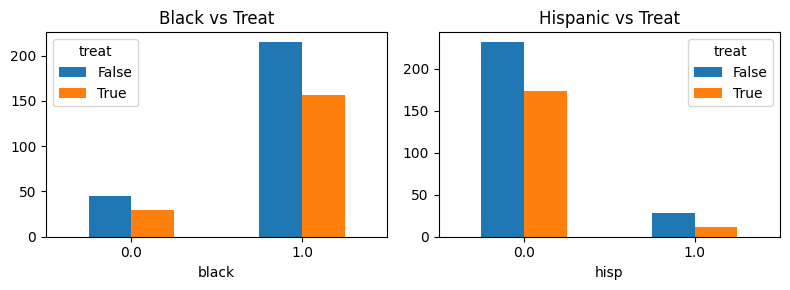

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# 2. Plot the first crosstab on the first axis (ax1)
### Creating crosstab
crosstb1 = pd.crosstab(lalonde_df.black, lalonde_df.treat)
### Creating barplot
barplot1 = crosstb1.plot.bar(ax=ax1, rot=0)
### Set title
ax1.set_title('Black vs Treat')

# 3. Plot the second crosstab on the second axis (ax2)
### Creating crosstab
crosstb2 = pd.crosstab(lalonde_df.hisp, lalonde_df.treat)
### Creating barplot
barplot2 = crosstb2.plot.bar(ax=ax2, rot=0)
### Set title
ax2.set_title('Hispanic vs Treat')

# 4. Plot figure
plt.tight_layout()
# plt.show()

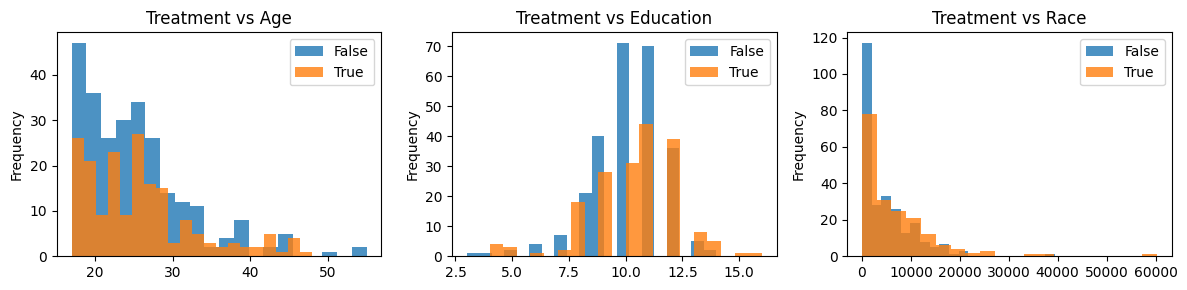

In [8]:
import matplotlib.pyplot as plt

# 1. Create a figure with 1 row and 2 columns
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3))

# 2. Plot the first crosstab on the first axis (ax1)
lalonde_df.groupby('treat')['age'].plot(ax=ax1, kind='hist', bins=20, alpha=0.8, legend=True)
ax1.set_title('Treatment vs Age')

# 3. Plot the second crosstab on the second axis (ax2)
lalonde_df.groupby('treat')['educ'].plot(ax=ax2, kind='hist', bins=20, alpha=0.8, legend=True)
ax2.set_title('Treatment vs Education')

# 4. Plot the third crosstab on the third axis (ax3)
lalonde_df.groupby('treat')['re78'].plot(ax=ax3, kind='hist', bins=20, alpha=0.8, legend=True)
ax3.set_title('Treatment vs Race')

# 5. Plot figure
plt.tight_layout()
# plt.show()

The dataset is unbalanced between treated and control groups, with clear differences in education, age, and ethnicity.
This causes issues in estimation, and propensity score methods adjust distributions using weights.


### 3.8.4: Estimation and Results

#### 3.8.4.1: Identification of Estimand

The estimand uses **treat** $T$ as treatment, **re78** $Y$ as outcome, and **nodegr**, **black**, **hisp**, **age**, **educ**, **married** as covariates.

In [9]:
from dowhy import CausalModel

model = CausalModel(
    data=lalonde_df,
    treatment='treat',
    outcome='re78',
    common_causes='nodegr+black+hisp+age+educ+married'.split('+'))
identified_estimand = model.identify_effect()

The causal graph ([Figure 3.30](#fig-causallalonde)) shows relationships between outcome, treatment and confounders.

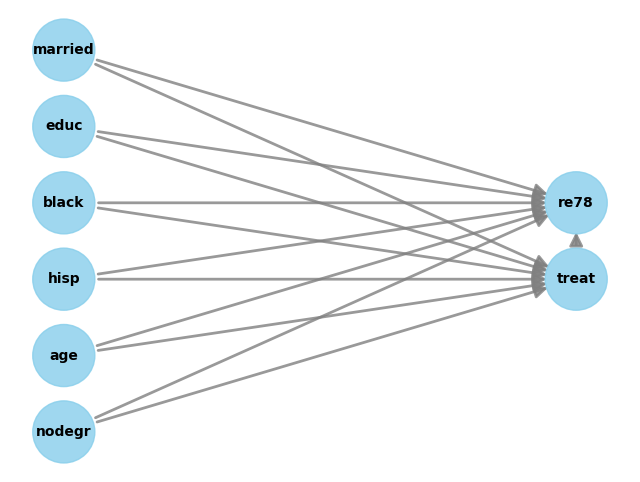

In [10]:
model.view_model()

<center>
  <a id="fig-causallalonde"></a>
  <h6>Figure 3.30: Causal Graph for Identification</h6>
</center>


#### 3.8.4.2: Estimation and Robustness

We examined multiple linear, non-linear, propensity-based and causal tree estimators for a comprehensive overview.

Simple linear regression results.

In [11]:
linear_regression_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    control_value=0,
    treatment_value=1
)
print(linear_regression_estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                                                
────────(E[re78|nodegr,age,hisp,black,educ,married])
d[treat]                                            
Estimand assumption 1, Unconfoundedness: If U→{treat} and U→re78 then P(re78|treat,nodegr,age,hisp,black,educ,married,U) = P(re78|treat,nodegr,age,hisp,black,educ,married)

## Realized estimand
b: re78~treat+nodegr+age+hisp+black+educ+married
Target units: ate

## Estimate
Mean value: 1671.1304316174092



Asymmetrical distributions between control and treated groups necessitated inverse propensity weighting.

In [12]:
causal_estimate_ipw = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting",
    target_units="ate",
    method_params={"weighting_scheme": "ips_weight"}
)
print(causal_estimate_ipw)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                                                
────────(E[re78|nodegr,age,hisp,black,educ,married])
d[treat]                                            
Estimand assumption 1, Unconfoundedness: If U→{treat} and U→re78 then P(re78|treat,nodegr,age,hisp,black,educ,married,U) = P(re78|treat,nodegr,age,hisp,black,educ,married)

## Realized estimand
b: re78~treat+nodegr+age+hisp+black+educ+married
Target units: ate

## Estimate
Mean value: 1639.840148951268



The **doWhy** library interprets distribution shifts.

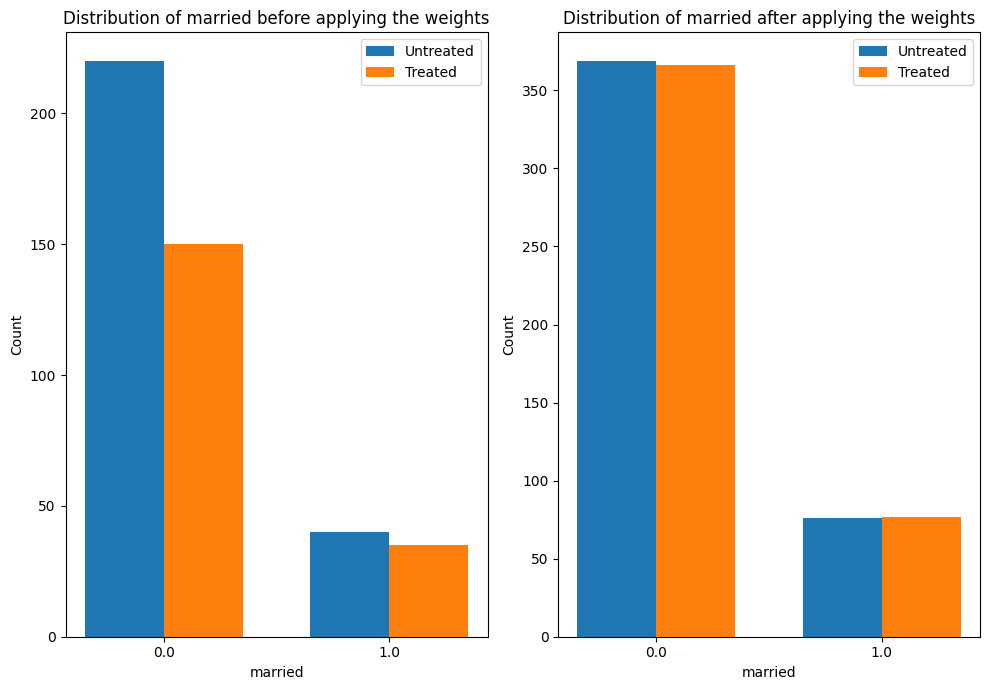

In [13]:
causal_estimate_ipw.interpret(
    method_name="confounder_distribution_interpreter",
    var_type='discrete',
    var_name='married',
    fig_size=(10, 7),
    font_size=12
)

<center>
  <a id="fig-propensitytechnique"></a>
  <h6>Married distribution before and after inverse propensity weighting</h6>
</center>

Table for Estimator Comparison:

| Estimator                       | ATE      |
|---------------------------------|----------|
| Naive                           | 1794.342 |
| Linear Regression               | 1671.13  |
| T-Learner                       | 1693.76  |
| X-Learner                       | 1763.83  |
| Double Machine Learner          | 1408.93  |
| Propensity Score Matching       | 1498.55  |
| Propensity Score Stratification | 1838.36  |
| Propensity Score and Weighting  | 1639.80  |


In [14]:
print('Naive Estimator:\n', (
        lalonde_df[lalonde_df['treat'] == 1].mean() -
        lalonde_df[lalonde_df['treat'] == 0].mean()
)['re78'])

Naive Estimator:
 1794.342404270271


In [15]:
linear_regression_estimate = model.estimate_effect(identified_estimand,
                                                   method_name="backdoor.linear_regression",
                                                   control_value=0,
                                                   treatment_value=1)
print('Linear Regression:\n', linear_regression_estimate)

Linear Regression:
 *** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                                                
────────(E[re78|nodegr,age,hisp,black,educ,married])
d[treat]                                            
Estimand assumption 1, Unconfoundedness: If U→{treat} and U→re78 then P(re78|treat,nodegr,age,hisp,black,educ,married,U) = P(re78|treat,nodegr,age,hisp,black,educ,married)

## Realized estimand
b: re78~treat+nodegr+age+hisp+black+educ+married
Target units: ate

## Estimate
Mean value: 1671.1304316174092



In [16]:
from sklearn.ensemble import RandomForestRegressor

t_learner_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.metalearners.TLearner",
    confidence_intervals=False,
    method_params={"init_params": {
        'models': RandomForestRegressor()
    },
        "fit_params": {}
    })
print('Meta Learner: T-Learner:\n', t_learner_estimate)

Meta Learner: T-Learner:
 *** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                                                
────────(E[re78|nodegr,age,hisp,black,educ,married])
d[treat]                                            
Estimand assumption 1, Unconfoundedness: If U→{treat} and U→re78 then P(re78|treat,nodegr,age,hisp,black,educ,married,U) = P(re78|treat,nodegr,age,hisp,black,educ,married)

## Realized estimand
b: re78~treat+nodegr+age+hisp+black+educ+married
Target units: ate

## Estimate
Mean value: 1717.7098863940237
Effect estimates: [[ 6.07134370e+03]
 [-2.28179469e+03]
 [-8.81166827e+02]
 [-8.84223045e+02]
 [-6.39380888e+03]
 [-8.84223045e+02]
 [-5.67604854e+03]
 [ 2.58187893e+03]
 [ 5.90965333e-01]
 [-1.13026205e+03]
 [ 1.22355373e+04]
 [ 6.63548023e+03]
 [ 1.63467686e+03]
 [ 7.75393075e+03]
 [ 4.84063871e+03]
 [ 8.05113143e+03]
 [-1.65213966e+03]
 [-5.5768318

/Users/stefanobragaglia/Workspace/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/stefanobragaglia/Workspace/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [19]:
from sklearn.ensemble import RandomForestRegressor

x_learner_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.metalearners.XLearner",
    confidence_intervals=False,
    method_params={"init_params": {
        'models': RandomForestRegressor()
    },
        "fit_params": {}
    })
print('### Meta Learner: X-Learner:\n', x_learner_estimate)

### Meta Learner: X-Learner:
 *** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                                                
────────(E[re78|nodegr,age,hisp,black,educ,married])
d[treat]                                            
Estimand assumption 1, Unconfoundedness: If U→{treat} and U→re78 then P(re78|treat,nodegr,age,hisp,black,educ,married,U) = P(re78|treat,nodegr,age,hisp,black,educ,married)

## Realized estimand
b: re78~treat+nodegr+age+hisp+black+educ+married
Target units: ate

## Estimate
Mean value: 1816.4079070338692
Effect estimates: [[ 4.83565879e+03]
 [ 2.04599390e+01]
 [-5.28774327e+02]
 [-2.55263360e+02]
 [-4.37080416e+03]
 [-2.55263360e+02]
 [-3.97422290e+03]
 [ 1.43134045e+03]
 [-1.11254275e+03]
 [-3.49311344e+02]
 [ 8.70761216e+03]
 [ 6.72942801e+03]
 [ 1.43266826e+03]
 [ 6.24033910e+03]
 [ 3.99583546e+03]
 [ 7.21657549e+03]
 [-1.78090843e+03]
 [-4.448

/Users/stefanobragaglia/Workspace/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/stefanobragaglia/Workspace/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [21]:
from sklearn.ensemble import RandomForestRegressor

causalforest_learner_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.dml.CausalForestDML",
    confidence_intervals=False,
    # Add the line below. Replace ['age', 'educ'] with your actual features.
    effect_modifiers=['age', 'educ', 'black', 'hisp', 'married', 'nodegree'],
    method_params={
        'init_params': {'model_y': RandomForestRegressor(),
                        'model_t': RandomForestRegressor()},
        'fit_params': {}
    })
print('Causal Forest:/n', causalforest_learner_estimate)

/Users/stefanobragaglia/Workspace/.venv/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/stefanobragaglia/Workspace/.venv/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Causal Forest:/n *** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                                                
────────(E[re78|nodegr,age,hisp,black,educ,married])
d[treat]                                            
Estimand assumption 1, Unconfoundedness: If U→{treat} and U→re78 then P(re78|treat,nodegr,age,hisp,black,educ,married,U) = P(re78|treat,nodegr,age,hisp,black,educ,married)

## Realized estimand
b: re78~treat+nodegr+age+hisp+black+educ+married | age,educ,black,hisp,married
Target units: ate

## Estimate
Mean value: 1270.5274990149655
Effect estimates: [[  676.30019537]
 [ 1896.94943781]
 [ -591.17650589]
 [ 1111.47733765]
 [ 1809.03614653]
 [ 1111.47733765]
 [ -984.25341209]
 [ 2798.19286907]
 [ -733.31765159]
 [  250.66399247]
 [ 1876.55016396]
 [ 2118.81275393]
 [ 2048.26994611]
 [-1810.50419701]
 [  931.8488369 ]
 [ 3016.68532774]
 [-1073.74319204]
 [ -155.

In [22]:

from sklearn.linear_model import LassoCV
from sklearn.ensemble import GradientBoostingRegressor

dml_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.dml.DML",
    method_params={
        'init_params': {'model_y': GradientBoostingRegressor(),
                        'model_t': GradientBoostingRegressor(),
                        'model_final': LassoCV(fit_intercept=False), },
        'fit_params': {}
    })
print('Double Machine Learner:/n', dml_estimate)

Double Machine Learner:/n *** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                                                
────────(E[re78|nodegr,age,hisp,black,educ,married])
d[treat]                                            
Estimand assumption 1, Unconfoundedness: If U→{treat} and U→re78 then P(re78|treat,nodegr,age,hisp,black,educ,married,U) = P(re78|treat,nodegr,age,hisp,black,educ,married)

## Realized estimand
b: re78~treat+nodegr+age+hisp+black+educ+married | 
Target units: ate

## Estimate
Mean value: 1742.1285943568723
Effect estimates: [[1742.12859436]]



/Users/stefanobragaglia/Workspace/.venv/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/Users/stefanobragaglia/Workspace/.venv/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [26]:
propensity_matching_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching",
    target_units="ate",
    method_params={})
#print(estimate)
print("Propensity Score Matching:\nCausal Estimate is ", str(propensity_matching_estimate.value))

Propensity Score Matching:
Causal Estimate is  1796.5383429213484


In [33]:
propensity_stratification_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_stratification",
    target_units="ate",
    method_params={
        "num_strata": 3  # Reduce this number (try 3 or 2)
    })
#print(estimate)
print("Propensity Score Stratification:\nCausal Estimate is " + str(propensity_stratification_estimate.value))

Propensity Score Stratification:
Causal Estimate is 1655.6226244074842


In [34]:
interpretation = propensity_stratification_estimate.interpret(
    method_name="propensity_balance_interpreter")

ValueError: No objects to concatenate

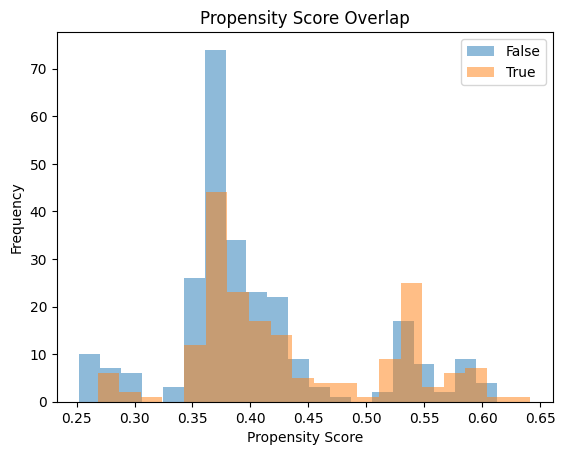

In [36]:
import matplotlib.pyplot as plt

# 1. Check for Overlap (Diagnosis)
# Access the data directly from the estimate object
# DoWhy estimates usually store the internal dataframe in ._data
df = propensity_stratification_estimate._data

# Check if 'propensity_score' column exists, then plot
if 'propensity_score' in df.columns:
    df.groupby('treat')['propensity_score'].plot(kind='hist',
                                                 bins=20,
                                                 alpha=0.5,
                                                 legend=True)
    plt.title("Propensity Score Overlap")
    plt.xlabel("Propensity Score")
    plt.show()
else:
    print("Propensity scores were not saved in the dataframe. Let's check the column names:")
    print(df.columns)

In [38]:
causal_estimate_ipw = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting",
    target_units="ate",
    method_params={
        "weighting_scheme": "ips_weight"
    })
print(causal_estimate_ipw)
print("Inverse Propensity Score weighting:\nCausal Estimate is " + str(causal_estimate_ipw.value))

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                                                
────────(E[re78|nodegr,age,hisp,black,educ,married])
d[treat]                                            
Estimand assumption 1, Unconfoundedness: If U→{treat} and U→re78 then P(re78|treat,nodegr,age,hisp,black,educ,married,U) = P(re78|treat,nodegr,age,hisp,black,educ,married)

## Realized estimand
b: re78~treat+nodegr+age+hisp+black+educ+married
Target units: ate

## Estimate
Mean value: 1639.840148951268

Inverse Propensity Score weighting:
Causal Estimate is 1639.840148951268


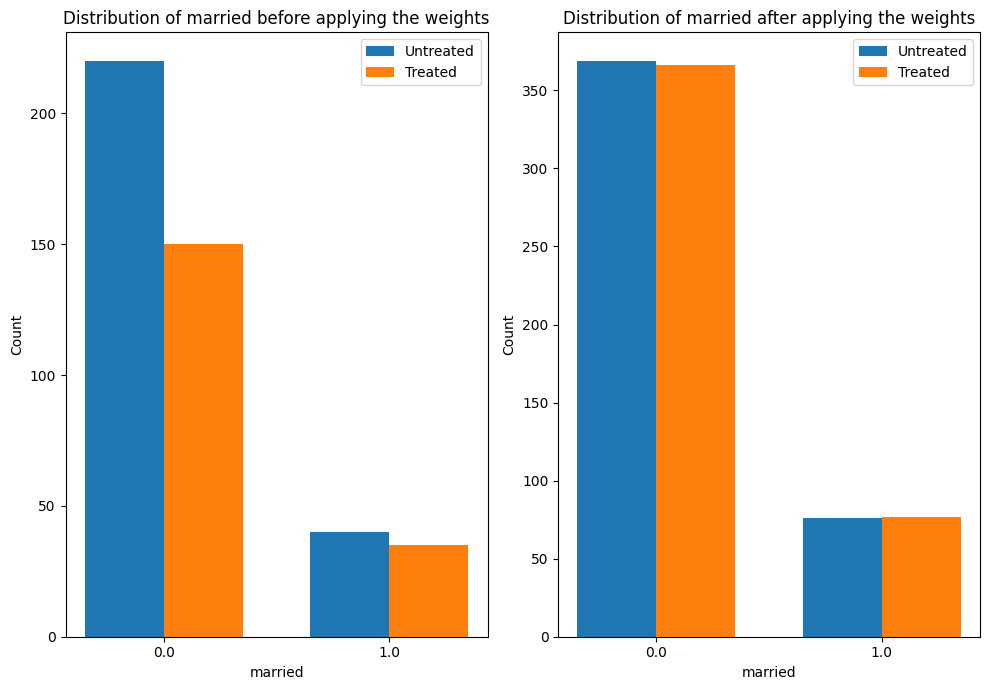

In [39]:
causal_estimate_ipw.interpret(
    method_name="confounder_distribution_interpreter",
    var_type='discrete',
    var_name='married',
    fig_size=(10, 7),
    font_size=12)

In [40]:
causal_estimate_ipw_self_normalized = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting",
    target_units="ate",
    method_params={
        "weighting_scheme": "ips_normalized_weight"
    })
print(causal_estimate_ipw_self_normalized)
print("Self-normalized IPS weighting:\nCausal Estimate is " + str(causal_estimate_ipw_self_normalized.value))

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                                                
────────(E[re78|nodegr,age,hisp,black,educ,married])
d[treat]                                            
Estimand assumption 1, Unconfoundedness: If U→{treat} and U→re78 then P(re78|treat,nodegr,age,hisp,black,educ,married,U) = P(re78|treat,nodegr,age,hisp,black,educ,married)

## Realized estimand
b: re78~treat+nodegr+age+hisp+black+educ+married
Target units: ate

## Estimate
Mean value: 1639.8401489512662

Self-normalized IPS weighting:
Causal Estimate is 1639.8401489512662


### 3.8.5: Refutation and Validation

We cover key validation and refutation tests on the model, as discussed in the chapter.


In [42]:
res_random = model.refute_estimate(
    identified_estimand,
    causal_estimate_ipw,
    method_name="random_common_cause",
    show_progress_bar=True)
print('Random common cause:\n', res_random)

Refuting Estimates: 100%|██████████| 100/100 [00:00<00:00, 503.80it/s]

Random common cause:
 Refute: Add a random common cause
Estimated effect:1639.840148951268
New effect:1639.840148951269
p value:1.0



#### 3.8.5.1: Removing Random Subset of Data

We use the inverse causal weighting estimate for refutation:

In [43]:
res_subset = model.refute_estimate(
    identified_estimand,
    causal_estimate_ipw,
    method_name="data_subset_refuter",
    show_progress_bar=True,
    subset_fraction=0.9
)
print('Removing a random subset of the data:/nRandom common cause:\n', res_random)

Refuting Estimates: 100%|██████████| 100/100 [00:00<00:00, 448.54it/s]

Removing a random subset of the data:/nRandom common cause:
 Refute: Add a random common cause
Estimated effect:1639.840148951268
New effect:1639.840148951269
p value:1.0



The difference is 17. With $p = 0.98 \gt 0.05$, we fail to reject the null hypothesis, indicating no significant effect from the refutation task.


#### 3.8.5.2: Placebo Treatment

Replacing treatment with placebo


<pre><code>
</code></pre>

<p>The output</p>

<pre><code>Refute: Use a Placebo Treatment
Estimated effect:1639.7956658905296
New effect:-209.15727259572515
p value:0.78
</code></pre>

In [44]:
res_placebo = model.refute_estimate(
    identified_estimand,
    causal_estimate_ipw,
    method_name="placebo_treatment_refuter",
    show_progress_bar=True,
    placebo_type="permute"
)
print('Placebo treatment:\n', res_placebo)

Refuting Estimates: 100%|██████████| 100/100 [00:00<00:00, 433.89it/s]

Placebo treatment:
 Refute: Use a Placebo Treatment
Estimated effect:1639.840148951268
New effect:-201.2357221975644
p value:0.76



#### 3.8.5.3: Sensitivity Analysis

Adding an unobserved common cause:


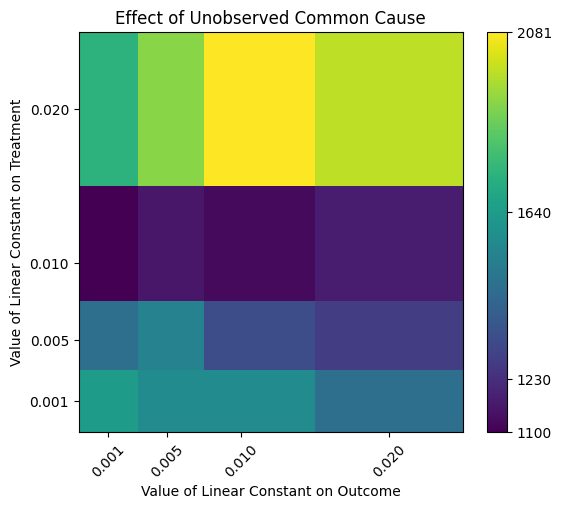

Refute: Add an Unobserved Common Cause
Estimated effect:1639.840148951268
New effect:(np.float64(1099.9203170319588), np.float64(2080.9720835720773))



In [47]:
# 1. Cast the treatment column to int in your dataframe
df['treat'] = df['treat'].astype(int)

# 2. Re-initialize your DoWhy model with the updated dataframe
model = CausalModel(
    data=lalonde_df,
    treatment='treat',
    outcome='re78',
    common_causes='nodegr+black+hisp+age+educ+married'.split('+'))
identified_estimand = model.identify_effect()

# 3. Re-run your estimation (necessary to refresh the internal estimate object)
causal_estimate_ipw = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting",
    target_units="ate",
    method_params={
        "weighting_scheme": "ips_weight"
    },
)

# 4. Now run the refutation
res_unobserved = model.refute_estimate(
    identified_estimand,
    causal_estimate_ipw,
    method_name="add_unobserved_common_cause",
    confounders_effect_on_treatment="binary_flip", confounders_effect_on_outcome="linear",
    effect_strength_on_treatment=[0.001, 0.005, 0.01, 0.02],
    effect_strength_on_outcome=[0.001, 0.005, 0.01, 0.02])
print(res_unobserved)

### 3.8.6: CATE Distributional Analysis


In [50]:
try:
    import causalml
except:
    """ Install causalml """
    !pip install causalml

y = lalonde_df['re78']
X = lalonde_df[['age', 'black', 'nodegr', 'hisp', 'educ', 'married']]
treatment = lalonde_df['treat']

from sklearn.model_selection import train_test_split

(
    X_train,
    X_test,
    y_train,
    y_test,
    treatment_train,
    treatment_test
) = train_test_split(X, y, treatment, test_size=0.1, random_state=42)

#### 3.8.6.1: Comparing MLP T-Learner and Linear Regression T-Learner for Comparison


In [52]:


from causalml.inference.meta import BaseTRegressor
from sklearn.linear_model import LinearRegression

from causalml.inference.meta import MLPTRegressor

learner_nn = MLPTRegressor(hidden_layer_sizes=(10, 10),
                           learning_rate_init=.1,
                           early_stopping=True,
                           random_state=42)
te, lb, ub = learner_nn.estimate_ate(X=X_train, treatment=treatment_train, y=y_train)
print('Average Treatment Effect (Neural Network (MLP)): {:.2f} ({:.2f}, {:.2f})'.format(te[0], lb[0], ub[0]))

# Calling the Base T-Learner class and feeding in LinearRegression
learner_t = BaseTRegressor(learner=LinearRegression())
ate_t_linear = learner_t.estimate_ate(X=X_train, treatment=treatment_train, y=y_train)
print('ATE estimate T-Learner Linear: {:.03f}'.format(ate_t_linear[0][0]))
print('ATE lower bound T- Learner Linear: {:.03f}'.format(ate_t_linear[1][0]))
print('ATE upper bound T- Learner Linear: {:.03f}'.format(ate_t_linear[2][0]))


Average Treatment Effect (Neural Network (MLP)): 2912.09 (1633.93, 4190.24)
ATE estimate T-Learner Linear: 1293.796
ATE lower bound T- Learner Linear: 43.450
ATE upper bound T- Learner Linear: 2544.141


In [53]:
cate_mlp_test = learner_nn.predict(X=X_test, treatment=treatment_test).flatten()
cate_t_test = learner_t.predict(X=X_test).flatten()


In [54]:
#### 3.8.6.2: Distribution of CATE Predictions by T-Learner and MLP-Regressor


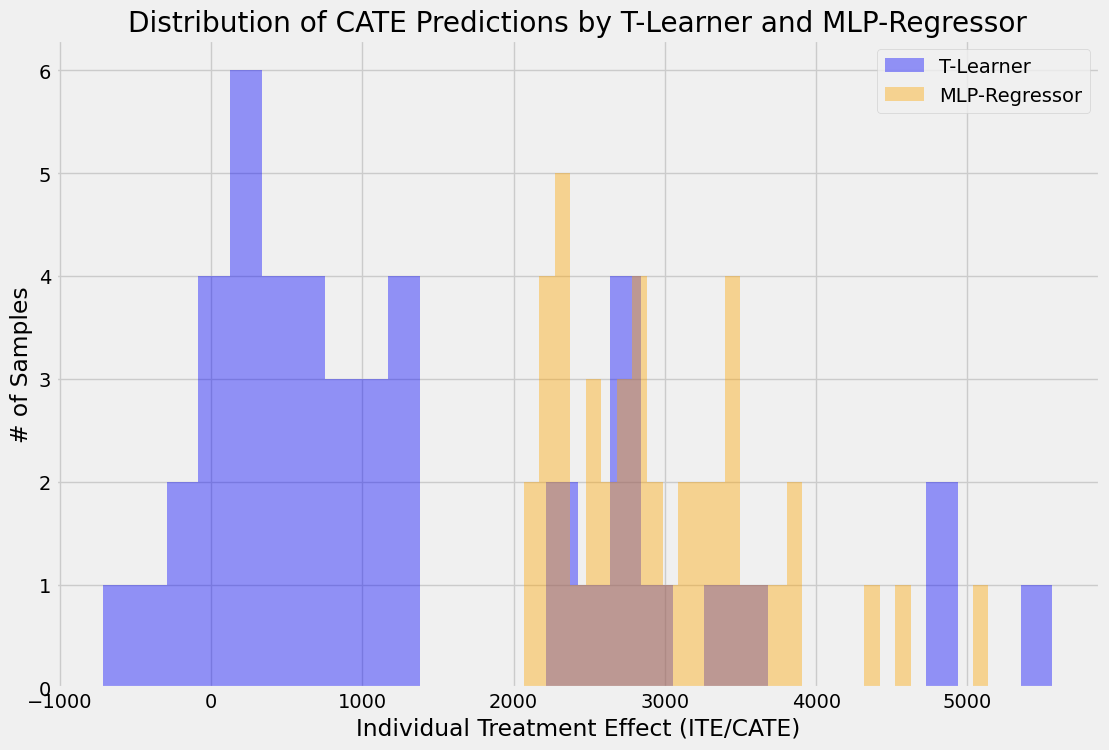

In [56]:
from matplotlib import pyplot as plt

alpha = 0.4
bins = 30
plt.figure(figsize=(12, 8))
plt.hist(cate_t_test, alpha=alpha, bins=bins, color='blue', label='T-Learner')
plt.hist(cate_mlp_test, alpha=alpha, bins=bins, color='orange', label='MLP-Regressor')

plt.title('Distribution of CATE Predictions by T-Learner and MLP-Regressor')
plt.xlabel('Individual Treatment Effect (ITE/CATE)')
plt.ylabel('# of Samples')
_ = plt.legend()

### 3.8.7: # Uplift Modeling and Analysis


In [58]:
! pip install python-json-logger kedro scikit-learn causallift

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(lalonde_df, stratify=lalonde_df['treat'], test_size=0.1, random_state=42)


  Using cached python_json_logger-4.0.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached kedro-1.2.0-py3-none-any.whl.metadata (14 kB)
  Using cached causallift-1.0.6-py3-none-any.whl.metadata (2.0 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached build-1.4.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached cachetools-7.0.5-py3-none-any.whl.metadata (5.6 kB)
  Using cached cookiecutter-2.7.1-py3-none-any.whl.metadata (7.3 kB)
  Using cached dynaconf-3.2.13-py2.py3-none-any.whl.metadata (9.4 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached kedro_telemetry-0.7.0-py3-none-any.whl.metadata (5.4 kB)
  Using cached more_itertools-10.8.0-py3-none-any.whl.metadata (39 kB)
  Using cached omegaconf-2.3.0-py3-none-any.whl.metadata (3.9 kB)
  Using cached parse-1.21.1-py2.py3-none-any.whl.metadata (21 kB)
  Using cached pluggy-1.6.0-py3-none-any.whl.metadata (4.8 k

#### 3.8.7.1: Estimate propensity scores for Inverse Probability Weighting


In [67]:
! pip uninstall -y python-json-logger
! pip install "python-json-logger<=2.1.0"
! pip uninstall -y kedro
! pip install "kedro<0.19.0"
! pip uninstall -y scikit-learn
! pip install "scikit-learn<=0.22.0"
! pip uninstall -y causallift
! pip install causallift

# pip install == kedro==0.17.7 scikit-learn==0.21.3 causallift


from causallift import CausalLift

print('\n[Estimate propensity scores for Inverse Probability Weighting.]')
cl = CausalLift(
    train_df,
    test_df,
    col_outcome='re78',
    col_treatment='treat',
    cols_features=['age', 'educ', 'black', 'hisp', 'married', 'nodegr'],
    enable_ipw=True,
    verbose=3
)

Found existing installation: python-json-logger 2.0.7
Uninstalling python-json-logger-2.0.7:
  Successfully uninstalled python-json-logger-2.0.7
  Using cached python_json_logger-2.0.7-py3-none-any.whl.metadata (6.5 kB)
Using cached python_json_logger-2.0.7-py3-none-any.whl (8.1 kB)
Found existing installation: kedro 0.18.14
Uninstalling kedro-0.18.14:
  Successfully uninstalled kedro-0.18.14
  Using cached kedro-0.18.14-py3-none-any.whl.metadata (25 kB)
Using cached kedro-0.18.14-py3-none-any.whl (281 kB)
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 8.9 MB/s  0:00:00 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [20 lines of output]
      Traceback (most recent call 

ImportError: cannot import name 'AbstractDataSet' from 'kedro.io' (/Users/stefanobragaglia/Workspace/.venv/lib/python3.12/site-packages/kedro/io/__init__.py)

#### 3.8.7.4: CATE Analysis on Test Dataset


In [60]:
print('\n[Create 2 models for treatment and untreatment and estimate CATE (Conditional Average Treatment Effects)]')
train_df, test_df = cl.estimate_cate_by_2_models()

print('\n[Show CATE for train dataset]')
display(train_df)
train_df.to_csv('CATE_for_Train.csv')

print('\n[Show CATE for test dataset]')
display(test_df)
# test_df.to_csv('CATE_for_Test.csv')


[Create 2 models for treatment and untreatment and estimate CATE (Conditional Average Treatment Effects)]


NameError: name 'cl' is not defined